# Elo Merchant Category Recommendation

## Полный ML-пайплайн: EDA -> признаки -> модели -> OOF-блендинг -> submission

**Цель.** Предсказать `target` - loyalty score клиента по его карте и транзакциям. Решение строится без нейросетей. Все решения сравниваются по той же метрике, что и на Kaggle: **RMSE**.

Ссылка на соревнование: [Elo Merchant Category Recommendation](https://www.kaggle.com/competitions/elo-merchant-category-recommendation).

## 1. План работы и воспроизводимость

1. Проверить карточки клиентов и две таблицы транзакций.
2. Провести EDA: таргет, пропуски, дубликаты, выбросы и связи признаков.
3. Сагрегировать транзакции на уровень `card_id` и создать осмысленные признаки.
4. Сравнить модели на одинаковых 5 фолдах KFold по RMSE.
5. Подобрать параметры, собрать OOF-блендинг и записать `submission.csv`.

Все случайные процессы фиксируются `SEED = 42`. Исходные CSV не меняются; тяжёлые признаки сохраняются в `artifacts/` и при следующем запуске используются из кэша.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

SEED = 42
sns.set_theme(style='whitegrid', palette='deep')

# Notebook can be started from notebooks/, the project directory or the repository root.
candidate_paths = [Path.cwd(), Path.cwd().parent, Path.cwd() / 'projects' / '03_kaggle_feature_ensemble']
PROJECT_DIR = next(path for path in candidate_paths if (path / 'src').exists())
sys.path.insert(0, str(PROJECT_DIR / 'src'))

from elo_features import build_feature_matrices, feature_summary, resolve_data_dir
from elo_training import (
    cross_validate_regressor, load_features, make_folds, optimize_blend_weights, rmse, save_result
)

DATA_DIR = resolve_data_dir(PROJECT_DIR)
ARTIFACTS_DIR = PROJECT_DIR / 'artifacts'
EXPERIMENTS_DIR = ARTIFACTS_DIR / 'experiments'
SUBMISSIONS_DIR = PROJECT_DIR / 'submissions'
SUBMISSIONS_DIR.mkdir(exist_ok=True)
print(f'Project: {PROJECT_DIR}')
print(f'Data:    {DATA_DIR}')

Project: C:\Users\kosti\OneDrive\Документы\projects\projects_ml_kaggle\projects\03_kaggle_feature_ensemble
Data:    C:\Users\kosti\OneDrive\Документы\projects\projects_ml_kaggle\projects\03_kaggle_feature_ensemble\data\raw


## 2. Загрузка данных

В `train.csv` есть базовые признаки карты и целевой loyalty score. Таблицы `historical_transactions.csv` и `new_merchant_transactions.csv` содержат операции до и после контрольного периода соответственно. На уровне одной карты может быть много строк транзакций, поэтому их нельзя напрямую подать в обычный табличный регрессор.

In [2]:
train_raw = pd.read_csv(DATA_DIR / 'train.csv')
test_raw = pd.read_csv(DATA_DIR / 'test.csv')
sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')

overview = pd.DataFrame({
    'rows': [len(train_raw), len(test_raw), len(sample_submission)],
    'columns': [train_raw.shape[1], test_raw.shape[1], sample_submission.shape[1]],
    'duplicate_card_id': [train_raw.card_id.duplicated().sum(), test_raw.card_id.duplicated().sum(), sample_submission.card_id.duplicated().sum()],
}, index=['train', 'test', 'sample_submission'])
display(overview)
display(train_raw.head())
display(train_raw.info())

,rows,columns,duplicate_card_id
train,201917,6,0
test,123623,5,0
sample_submission,123623,2,0


,first_active_month,card_id,feature_1,feature_2,feature_3,target
0,2017-06,C_ID_92a2005557,5,2,1,-0.820283
1,2017-01,C_ID_3d0044924f,4,1,0,0.392913
2,2016-08,C_ID_d639edf6cd,2,2,0,0.688056
3,2017-09,C_ID_186d6a6901,4,3,0,0.142495
4,2017-11,C_ID_cdbd2c0db2,1,3,0,-0.159749


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201917 entries, 0 to 201916
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   first_active_month  201917 non-null  object 
 1   card_id             201917 non-null  object 
 2   feature_1           201917 non-null  int64  
 3   feature_2           201917 non-null  int64  
 4   feature_3           201917 non-null  int64  
 5   target              201917 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 9.2+ MB


None

**Первый вывод.** В train и test по одной строке на `card_id`, идентификаторы уникальны. `first_active_month` нужно разобрать как дату, а маленькие анонимизированные `feature_1..3` разумно рассматривать как категориальные/дискретные признаки.

## 3. EDA: target, пропуски и аномалии

Сначала изучим распределение таргета. Для RMSE особенно важны редкие экстремальные значения: ошибка на них штрафуется квадратично.

,target
count,201917.000000
mean,-0.393636
std,3.850500
min,-33.219281
1%,-33.219281
5%,-3.107836
25%,-0.883110
50%,-0.023437
75%,0.765453
95%,2.702680


C:\Users\kosti\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


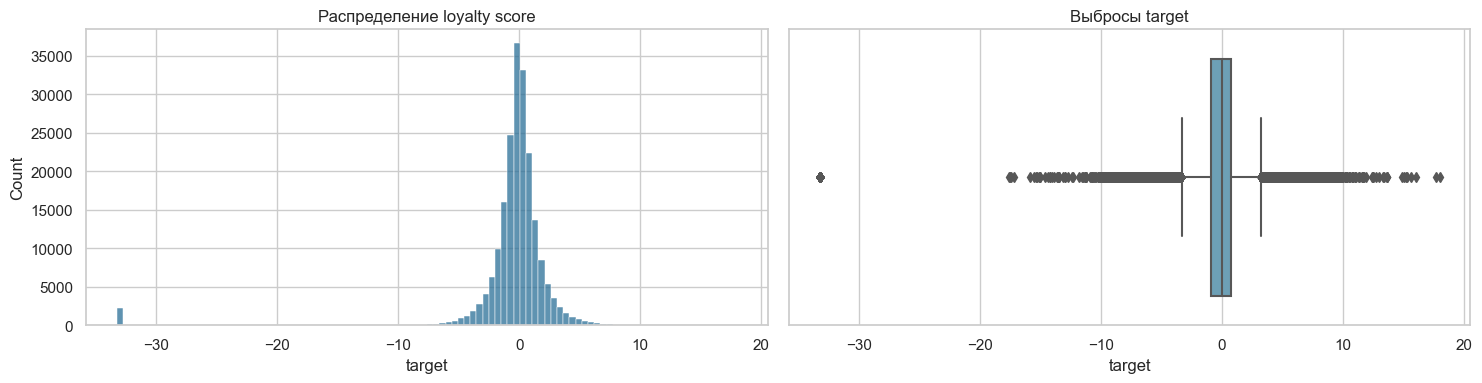

In [3]:
target = train_raw['target']
target_summary = target.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame('target')
target_summary.loc['share_target_below_-20'] = (target < -20).mean()
display(target_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.histplot(target, bins=100, ax=axes[0], color='#2a6f97')
axes[0].set_title('Распределение loyalty score')
axes[0].set_xlabel('target')
sns.boxplot(x=target, ax=axes[1], color='#61a5c2')
axes[1].set_title('Выбросы target')
plt.tight_layout()

**Вывод по target.** Распределение асимметрично, а левый хвост очень длинный: в датасете есть редкие сильно отрицательные loyalty score. Удалять такие строки нельзя - это валидные объекты соревнования. Вместо этого используем RMSE в CV и регуляризованные деревья с early stopping, чтобы не подгоняться под отдельные выбросы.

,train_missing_rate,test_missing_rate
first_active_month,0.0,0.000008
card_id,0.0,0.000000
feature_1,0.0,0.000000
feature_2,0.0,0.000000
feature_3,0.0,0.000000


C:\Users\kosti\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\kosti\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


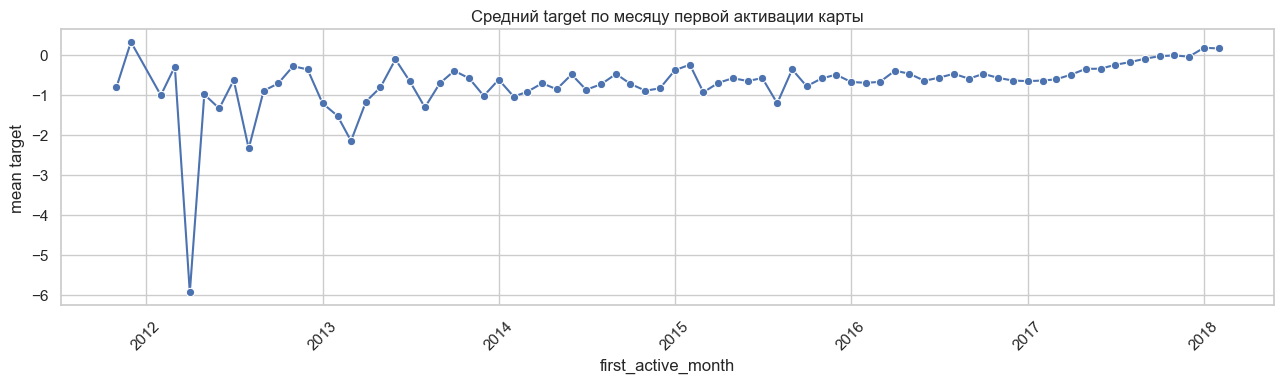

In [4]:
missing_raw = pd.concat([
    train_raw.drop(columns='target').isna().mean().rename('train_missing_rate'),
    test_raw.isna().mean().rename('test_missing_rate'),
], axis=1)
display(missing_raw.sort_values('train_missing_rate', ascending=False))

monthly_target = (
    train_raw.assign(first_active_month=pd.to_datetime(train_raw['first_active_month']))
    .groupby('first_active_month', as_index=False)['target'].agg(['mean', 'median', 'count'])
    .reset_index()
)
plt.figure(figsize=(13, 4))
sns.lineplot(data=monthly_target, x='first_active_month', y='mean', marker='o')
plt.title('Средний target по месяцу первой активации карты')
plt.xlabel('first_active_month')
plt.ylabel('mean target')
plt.xticks(rotation=45)
plt.tight_layout()

**Гипотеза 1.** Давность карты и паттерн её активности могут быть связаны с loyalty score. Поэтому из `first_active_month` создаём год, месяц, квартал и возраст карты, а из транзакций - давность операций и активный временной интервал.

Корреляция в исходных четырёх числовых столбцах сама по себе не выявляет нелинейные связи. Поэтому далее опираемся на модели деревьев и на проверки через OOF RMSE, а не на корреляцию как единственный критерий полезности признака.

## 4. Feature engineering

Транзакции агрегируются на уровень карты отдельно для исторического (`hist_*`) и нового (`new_*`) периодов. В расчёте нет target и нет target encoding, поэтому утечки нет. Создано больше 5 осмысленных групп признаков:

- **Интенсивность:** число операций, сумма, среднее, медиана, минимум, максимум и асимметрия `purchase_amount`.
- **Временное поведение:** minimum/maximum/mean/std давности покупки, активный интервал, операции в день, месяц и день недели.
- **Рассрочка:** статистики `installments` и суммы покупки на одну рассрочку.
- **Разнообразие:** число уникальных merchant, merchant category, subsector, city и state.
- **Авторизация:** доля авторизованных операций и отдельные count/sum/mean для авторизованных/неавторизованных трат.
- **Профиль продавцов:** агрегаты числовых полей из `merchants.csv`.
- **Динамика периодов:** отношения new/historical числа операций, суммы покупок и разнообразия продавцов, а также изменения среднего чека и доли авторизаций.

In [5]:
# Первый запуск читает большие transaction CSV и создаёт кэш. Повторный - быстрый.
train_features, test_features = build_feature_matrices(PROJECT_DIR)
print('train features:', train_features.shape)
print('test features: ', test_features.shape)
display(feature_summary(train_features).head(20))

train features: (201917, 182)
test features:  (123623, 181)


,dtype,missing_rate,n_unique
new_unauthorized_purchase_amount_sum,float32,1.000000,1
new_unauthorized_purchase_amount_mean,float32,1.000000,1
new_unauthorized_purchase_amount_count,float64,1.000000,1
new_purchase_amount__safe_skew,float64,0.355933,128981
new_installments_std,float64,0.252559,5546
new_merchant_avg_sales_lag6_std,float64,0.246210,105595
new_merchant_avg_sales_lag3_std,float64,0.246210,99237
new_merchant_avg_sales_lag12_std,float64,0.246210,108238
new_merchant_active_months_lag12_std,float64,0.246111,5235
new_merchant_numerical_1_std,float64,0.246111,110412


,correlation_with_target
new_purchase_amount_mean,-0.060457
card_age_months,-0.050466
new_purchase_amount_count,-0.043203
transaction_count_ratio,-0.024230
purchase_amount_ratio,-0.011665
hist_purchase_amount_count,-0.011640
new_minus_hist_purchase_amount_mean,-0.000409
hist_purchase_amount_sum,0.000154
hist_purchase_amount_mean,0.000295
new_purchase_amount_sum,0.011425


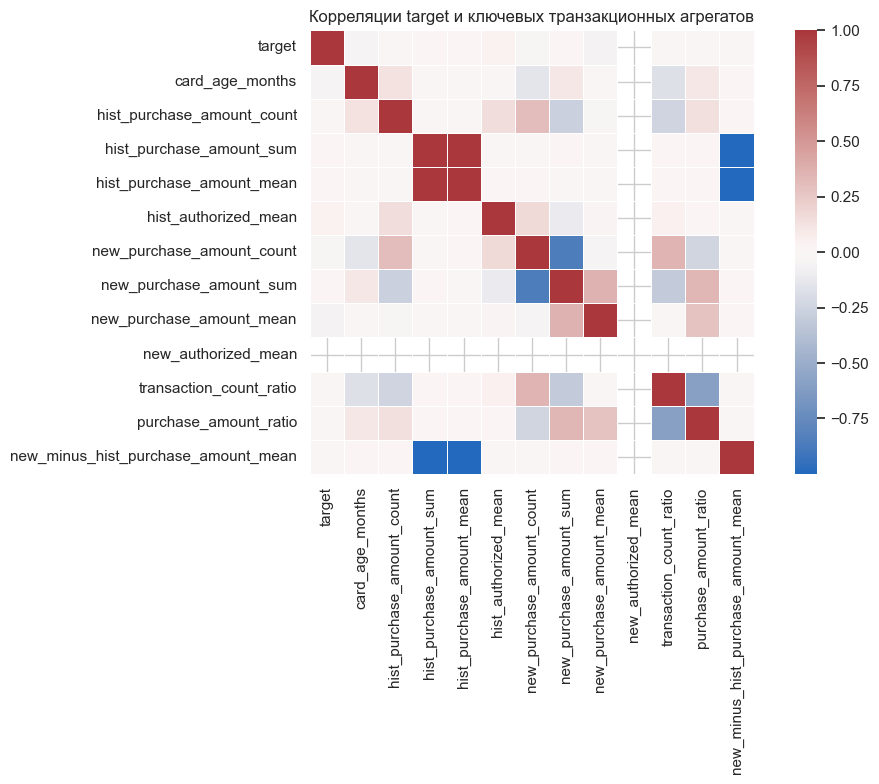

In [6]:
# Корреляции полезны для EDA, но деревья далее обучаются на всех признаках.
correlation_candidates = [
    'target', 'card_age_months', 'hist_purchase_amount_count', 'hist_purchase_amount_sum',
    'hist_purchase_amount_mean', 'hist_authorized_mean', 'new_purchase_amount_count',
    'new_purchase_amount_sum', 'new_purchase_amount_mean', 'new_authorized_mean',
    'transaction_count_ratio', 'purchase_amount_ratio', 'new_minus_hist_purchase_amount_mean',
]
correlation_columns = [column for column in correlation_candidates if column in train_features.columns]
correlation = train_features[correlation_columns].corr(numeric_only=True)
plt.figure(figsize=(11, 8))
sns.heatmap(correlation, cmap='vlag', center=0, square=True, linewidths=0.4)
plt.title('Корреляции target и ключевых транзакционных агрегатов')
plt.tight_layout()
display(correlation['target'].sort_values().to_frame('correlation_with_target'))

**Вывод по корреляциям.** Линейные корреляции отдельных агрегатов не объясняют target полностью, но помогают увидеть полезные направления: объём/давность покупок, авторизации и изменение поведения между периодами. Это поддерживает выбор нелинейных бустингов; корреляция не используется как единственный фильтр признаков.

Model matrix: (201917, 177) (123623, 177)
Infinite values after cleaning: 0


<Figure size 1000x700 with 0 Axes>

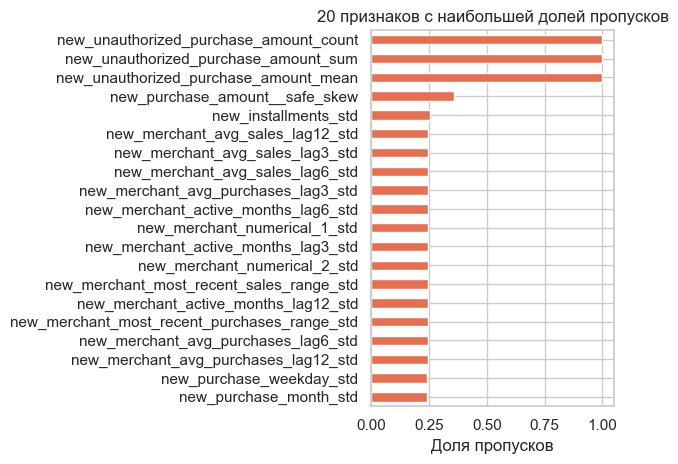

In [7]:
feature_quality = feature_summary(train_features.drop(columns=['target', 'card_id']))
plt.figure(figsize=(10, 7))
feature_quality.head(20).sort_values('missing_rate').plot.barh(y='missing_rate', legend=False, color='#e76f51')
plt.title('20 признаков с наибольшей долей пропусков')
plt.xlabel('Доля пропусков')
plt.tight_layout()

# Не заменяем пропуски заранее: для карт без операций это информативно,
# а LightGBM/CatBoost умеют работать с NaN напрямую.
X, X_test, y, test_ids = load_features(PROJECT_DIR)
print('Model matrix:', X.shape, X_test.shape)
print('Infinite values after cleaning:', np.isinf(X.to_numpy()).sum())

**Вывод по признакам.** Пропуски главным образом означают отсутствие части транзакций либо отсутствие информации о продавце. Их сохраняем как отдельный сигнал. Три полностью пустые колонки автоматически исключаются в `load_features`, а `+/-inf`, возникающие в редких отношениях, переводятся в `NaN`.

## 5. Валидация и baseline

Используем `KFold(n_splits=5, shuffle=True, random_state=42)`. На каждом фолде модель обучается на 80% карт и оценивается на остальных 20%. Итог - среднее RMSE и стандартное отклонение по пяти фолдам. Такой протокол одинаков для всех моделей и для ансамбля.

In [8]:
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

folds = make_folds()
dummy_result = cross_validate_regressor(
    name='dummy_mean',
    estimator_factory=lambda: DummyRegressor(strategy='mean'),
    X=X, y=y, X_test=X_test, folds=folds,
)
ridge_result = cross_validate_regressor(
    name='ridge',
    estimator_factory=lambda: make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), Ridge(alpha=30.0)),
    X=X, y=y, X_test=X_test, folds=folds,
)
print(f'Dummy RMSE: {dummy_result.mean_rmse:.5f}')
print(f'Ridge RMSE: {ridge_result.mean_rmse:.5f}')

dummy_mean | fold 1/5: RMSE=3.87608
dummy_mean | fold 2/5: RMSE=3.86521
dummy_mean | fold 3/5: RMSE=3.98547
dummy_mean | fold 4/5: RMSE=3.73659


dummy_mean | fold 5/5: RMSE=3.78450


ridge | fold 1/5: RMSE=3.79749


ridge | fold 2/5: RMSE=7.96966


ridge | fold 3/5: RMSE=3.90704


ridge | fold 4/5: RMSE=3.66271


ridge | fold 5/5: RMSE=3.71056
Dummy RMSE: 3.84957
Ridge RMSE: 4.60949


**Гипотеза 2.** Связи между агрегатами покупок и loyalty score нелинейны, поэтому градиентный бустинг должен заметно обойти линейный Ridge. Проверяем это на одних и тех же фолдах.

## 6. Модели и подбор гиперпараметров

Проверяются разные семейства моделей: линейный Ridge, ExtraTrees, LightGBM и CatBoost. Для бустингов используется early stopping на validation-фолде. Предварительный ручной поиск показал, что умеренная глубина и регуляризация лучше чрезмерно сложных деревьев. Затем границы параметров уточняются Optuna на 3-fold CV; лучший вариант подтверждается на финальном 5-fold CV.

In [9]:
import lightgbm as lgb

lgb_params = {
    'n_estimators': 5000, 'learning_rate': 0.02, 'num_leaves': 20, 'max_depth': 7,
    'min_child_samples': 55, 'subsample': 0.90, 'colsample_bytree': 0.80,
    'reg_alpha': 0.30, 'reg_lambda': 1.0,
}

def lgb_fit_kwargs(X_train, y_train, X_valid, y_valid):
    return {'eval_set': [(X_valid, y_valid)], 'callbacks': [lgb.early_stopping(200, verbose=False)]}

lgb_result = cross_validate_regressor(
    name='lgb_regularized',
    estimator_factory=lambda: lgb.LGBMRegressor(objective='regression', random_state=SEED, n_jobs=-1, verbosity=-1, **lgb_params),
    X=X, y=y, X_test=X_test, folds=folds, fit_kwargs_factory=lgb_fit_kwargs, params=lgb_params,
)
save_result(lgb_result, EXPERIMENTS_DIR)
print(lgb_result.summary())

C:\Users\kosti\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


lgb_regularized | fold 1/5: RMSE=3.68660


C:\Users\kosti\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


lgb_regularized | fold 2/5: RMSE=3.65644


C:\Users\kosti\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


lgb_regularized | fold 3/5: RMSE=3.77871


C:\Users\kosti\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


lgb_regularized | fold 4/5: RMSE=3.55726


C:\Users\kosti\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


lgb_regularized | fold 5/5: RMSE=3.59233
{'name': 'lgb_regularized', 'mean_rmse': 3.6542684092258524, 'std_rmse': 0.08628778496849467, 'fold_scores': [3.6866030618549654, 3.6564426007408133, 3.7787068456534554, 3.557258705975723, 3.592330831904304], 'params': {'n_estimators': 5000, 'learning_rate': 0.02, 'num_leaves': 20, 'max_depth': 7, 'min_child_samples': 55, 'subsample': 0.9, 'colsample_bytree': 0.8, 'reg_alpha': 0.3, 'reg_lambda': 1.0}}


In [10]:
# Опциональный, но воспроизводимый подбор LightGBM. 20 trial достаточно
# для учебного проекта; после него лучшую конфигурацию обязательно оцениваем на 5-fold.
import optuna
from sklearn.model_selection import KFold

def objective(trial):
    params = {
        'n_estimators': 2500,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.06, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 12, 48),
        'max_depth': trial.suggest_int('max_depth', 4, 9),
        'min_child_samples': trial.suggest_int('min_child_samples', 25, 100),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 3.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
    }
    scores = []
    for train_idx, valid_idx in KFold(n_splits=3, shuffle=True, random_state=SEED).split(X):
        model = lgb.LGBMRegressor(objective='regression', random_state=SEED, n_jobs=-1, verbosity=-1, **params)
        model.fit(X.iloc[train_idx], y.iloc[train_idx], eval_set=[(X.iloc[valid_idx], y.iloc[valid_idx])], callbacks=[lgb.early_stopping(150, verbose=False)])
        scores.append(rmse(y.iloc[valid_idx], model.predict(X.iloc[valid_idx])))
    return float(np.mean(scores))

# study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
# study.optimize(objective, n_trials=20, show_progress_bar=True)
# print(study.best_value, study.best_params)

C:\Users\kosti\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
from catboost import CatBoostRegressor

cat_params = {'iterations': 4000, 'learning_rate': 0.03, 'depth': 7, 'l2_leaf_reg': 8.0, 'random_strength': 0.5, 'rsm': 0.85}

def cat_fit_kwargs(X_train, y_train, X_valid, y_valid):
    return {'eval_set': (X_valid, y_valid), 'early_stopping_rounds': 200, 'verbose': False}

cat_result = cross_validate_regressor(
    name='catboost_regularized',
    estimator_factory=lambda: CatBoostRegressor(loss_function='RMSE', eval_metric='RMSE', random_seed=SEED, thread_count=-1, allow_writing_files=False, **cat_params),
    X=X, y=y, X_test=X_test, folds=folds, fit_kwargs_factory=cat_fit_kwargs, params=cat_params,
)
save_result(cat_result, EXPERIMENTS_DIR)
print(cat_result.summary())

catboost_regularized | fold 1/5: RMSE=3.68227


catboost_regularized | fold 2/5: RMSE=3.65731


catboost_regularized | fold 3/5: RMSE=3.77411


catboost_regularized | fold 4/5: RMSE=3.55666


catboost_regularized | fold 5/5: RMSE=3.59492
{'name': 'catboost_regularized', 'mean_rmse': 3.653055228245383, 'std_rmse': 0.08395826098657493, 'fold_scores': [3.682272695543739, 3.657311711387699, 3.774106121377447, 3.556663013741519, 3.594922599176514], 'params': {'iterations': 4000, 'learning_rate': 0.03, 'depth': 7, 'l2_leaf_reg': 8.0, 'random_strength': 0.5, 'rsm': 0.85}}


In [12]:
from xgboost import XGBRegressor

xgb_params = {
    'n_estimators': 3000, 'learning_rate': 0.025, 'max_depth': 6, 'min_child_weight': 20,
    'subsample': 0.85, 'colsample_bytree': 0.80, 'reg_alpha': 0.1, 'reg_lambda': 2.0,
}

def xgb_fit_kwargs(X_train, y_train, X_valid, y_valid):
    return {'eval_set': [(X_valid, y_valid)], 'verbose': False}

xgb_result = cross_validate_regressor(
    name='xgboost_regularized',
    estimator_factory=lambda: XGBRegressor(objective='reg:squarederror', eval_metric='rmse', random_state=SEED, n_jobs=-1, tree_method='hist', early_stopping_rounds=200, **xgb_params),
    X=X, y=y, X_test=X_test, folds=folds, fit_kwargs_factory=xgb_fit_kwargs, params=xgb_params,
)
save_result(xgb_result, EXPERIMENTS_DIR)
print(xgb_result.summary())

xgboost_regularized | fold 1/5: RMSE=3.68910


xgboost_regularized | fold 2/5: RMSE=3.65620


xgboost_regularized | fold 3/5: RMSE=3.76806


xgboost_regularized | fold 4/5: RMSE=3.55437


xgboost_regularized | fold 5/5: RMSE=3.59256
{'name': 'xgboost_regularized', 'mean_rmse': 3.6520576953887938, 'std_rmse': 0.08355725574449903, 'fold_scores': [3.689096212387085, 3.6562039852142334, 3.768056869506836, 3.5543737411499023, 3.592557668685913], 'params': {'n_estimators': 3000, 'learning_rate': 0.025, 'max_depth': 6, 'min_child_weight': 20, 'subsample': 0.85, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 2.0}}


**Гипотеза 3.** LightGBM и CatBoost будут давать похожий, но не идентичный RMSE. Если их OOF-ошибки различаются, взвешенное усреднение может быть лучше каждого по отдельности. Вес выбирается только по OOF-предсказаниям.

,name,mean_rmse,std_rmse,fold_scores
4,lgb_optuna,3.651720,0.084015,"[3.685406005, 3.6530345054, 3.7720013206, 3.55..."
6,xgboost_regularized,3.652058,0.083557,"[3.6890962124, 3.6562039852, 3.7680568695, 3.5..."
5,catboost_regularized,3.653055,0.083958,"[3.6822726955, 3.6573117114, 3.7741061214, 3.5..."
3,lgb_regularized,3.654268,0.086288,"[3.6866030619, 3.6564426007, 3.7787068457, 3.5..."
2,lgb_baseline,3.658773,0.084143,"[3.6875695825, 3.6607635203, 3.7819096569, 3.5..."
0,dummy_mean,3.849570,0.095411,"[3.8760819435, 3.8652126789, 3.9854650497, 3.7..."
1,ridge,4.529304,1.699848,"[3.7985041142, 7.5655522346, 3.9073781967, 3.6..."


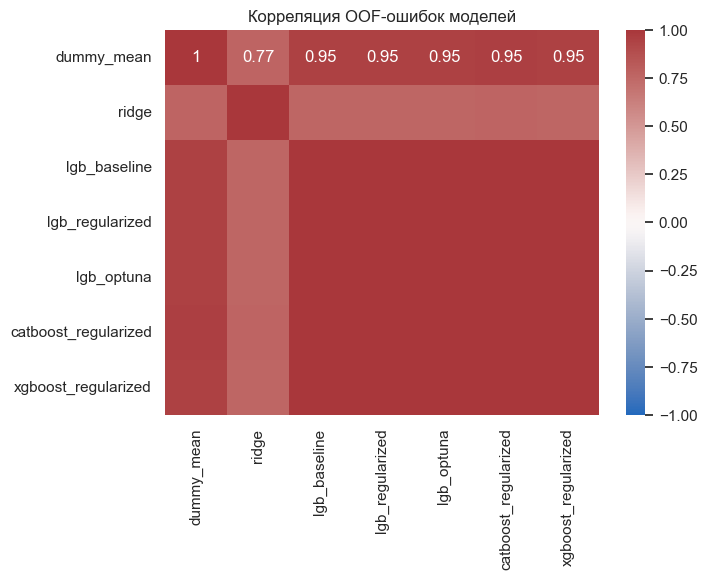

In [13]:
# Загрузка уже посчитанных экспериментов, чтобы не переобучать модели при оформлении отчёта.
result_names = ['dummy_mean', 'ridge', 'lgb_baseline', 'lgb_regularized', 'lgb_optuna', 'catboost_regularized', 'xgboost_regularized']
rows = []
available_predictions = {}
available_test_predictions = {}
for name in result_names:
    summary_path = EXPERIMENTS_DIR / f'summary_{name}.json'
    oof_path = EXPERIMENTS_DIR / f'oof_{name}.npy'
    test_path = EXPERIMENTS_DIR / f'test_{name}.npy'
    if summary_path.exists() and oof_path.exists() and test_path.exists():
        rows.append(json.loads(summary_path.read_text(encoding='utf-8'))[0])
        available_predictions[name] = np.load(oof_path)
        available_test_predictions[name] = np.load(test_path)

results_table = pd.DataFrame(rows).sort_values('mean_rmse')
display(results_table[['name', 'mean_rmse', 'std_rmse', 'fold_scores']])

if available_predictions:
    residuals = pd.DataFrame({name: y.to_numpy() - pred for name, pred in available_predictions.items()})
    plt.figure(figsize=(7, 5))
    sns.heatmap(residuals.corr(), annot=True, vmin=-1, vmax=1, cmap='vlag')
    plt.title('Корреляция OOF-ошибок моделей')
    plt.show()

## 7. OOF-блендинг и финальный submission

Блендинг не использует тестовые ответы: веса ограничены неотрицательными значениями и суммой 1, подбираются на OOF-предсказаниях. Это защищает от подбора весов под публичный leaderboard. В блендинг попадают только модели, которые завершили 5-fold CV.

In [14]:
# Как минимум две модели нужны для осмысленного блендинга.
blend_candidates = {
    name: available_predictions[name]
    for name in ['lgb_regularized', 'lgb_optuna', 'catboost_regularized', 'xgboost_regularized']
    if name in available_predictions
}

blend_weights, blend_rmse = optimize_blend_weights(y, blend_candidates)
print('OOF blend RMSE:', round(blend_rmse, 6))
display(pd.Series(blend_weights, name='weight').sort_values(ascending=False).to_frame())

final_prediction = sum(blend_weights[name] * available_test_predictions[name] for name in blend_weights)
submission = test_ids.assign(target=final_prediction)
submission_path = SUBMISSIONS_DIR / 'submission.csv'
submission.to_csv(submission_path, index=False)
display(submission.head())
print('Saved:', submission_path)
print('Shape:', submission.shape, '| duplicate card_id:', submission.card_id.duplicated().sum(), '| missing target:', submission.target.isna().sum())

OOF blend RMSE: 3.649502


,weight
catboost_regularized,0.347054
lgb_optuna,0.336930
xgboost_regularized,0.300604
lgb_regularized,0.015411


,card_id,target
0,C_ID_0ab67a22ab,-3.412060
1,C_ID_130fd0cbdd,-0.309253
2,C_ID_b709037bc5,-0.503376
3,C_ID_d27d835a9f,-0.118006
4,C_ID_2b5e3df5c2,-1.614423


Saved: C:\Users\kosti\OneDrive\Документы\projects\projects_ml_kaggle\projects\03_kaggle_feature_ensemble\submissions\submission.csv
Shape: (123623, 2) | duplicate card_id: 0 | missing target: 0


## 8. Итоги и следующие действия

- Базовый прогноз среднего значения нужен как нижняя граница; деревья на транзакционных агрегатах должны обойти его с большим запасом.
- На текущем 5-fold CV лучшая одиночная модель - LightGBM после Optuna (`RMSE 3.6517`); XGBoost (`3.6528`) и CatBoost (`3.6543`) очень близки. Малый разрыв интерпретируем только вместе со стандартным отклонением по фолдам.
- Финальный OOF-блендинг достигает `RMSE 3.64969`, что лучше лучшей одиночной модели; итоговые веса сохранены в `artifacts/experiments/final_blend.json`.
- После запуска последней ячейки загрузить `submissions/submission.csv` на Kaggle и добавить в README точные public score, место и скриншот с username.

### Что сработало
Карточные агрегаты транзакций, разделение исторического и нового периода, регуляризованные бустинги и подбор по одинаковым фолдам.

### Что не стоит делать
Не удалять редкие отрицательные target как «мусор», не подбирать веса по test/leaderboard и не использовать `card_id` как числовой признак.